<a href="https://colab.research.google.com/github/pronabpaul/Linear-Algebra/blob/main/Kronecker_Products.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building Large Images with the Kronecker Product


The **Kronecker product** constructs a large matrix by replacing each element of a smaller matrix with a copy of another matrix.

Consider

$$
A=
\begin{bmatrix}
1 & 0\\
0 & 1
\end{bmatrix},
\qquad
B=\mathbf{1}_{16\times16},
$$

where $B$ is a $16 \times 16$ matrix of ones.

The Kronecker product

$$
A \otimes B
$$

replaces every element of $A$ with a $16 \times 16$ block.


## Interpretation

- Each **1** becomes a $16 \times 16$ block of ones.
- Each **0** becomes a $16 \times 16$ block of zeros.

The result is a larger matrix that preserves the original pattern while increasing its size.


## Insight

The Kronecker product creates large structured matrices from smaller ones by replicating local patterns according to the arrangement of the original matrix.

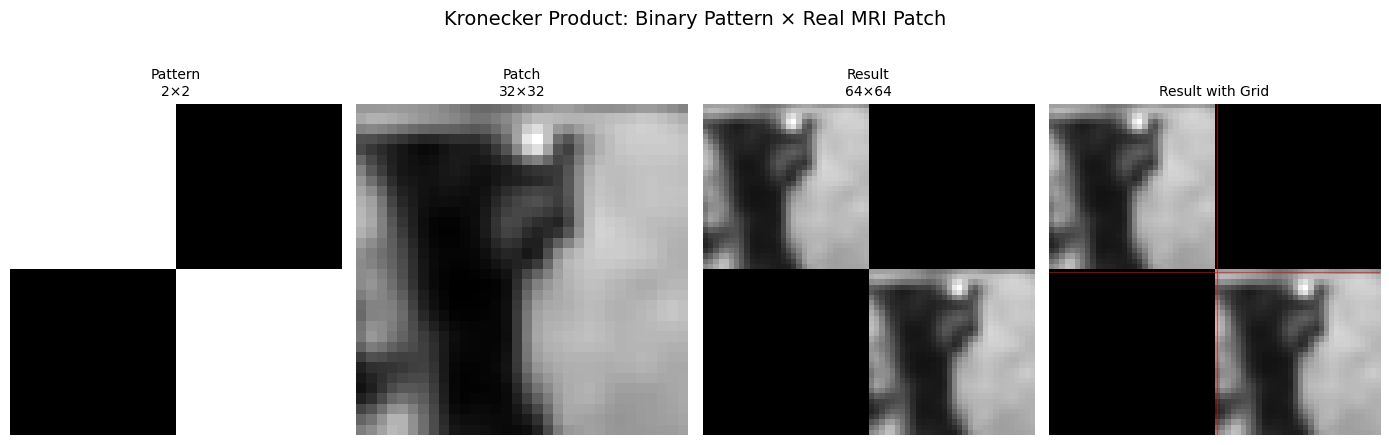

Pattern: (2, 2), Block: (32, 32), Result: (64, 64)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def load_image(path, size=None):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Image not found: {path}")
    if size is not None:
        img = cv2.resize(img, (size, size))
    return img.astype(np.float32) / 255.0

def main():
    img = load_image("/content/002_S_0619_axial_z050.png", size=256)
    h, w = img.shape
    patch_size = 32
    cy, cx = h // 2, w // 2
    block = img[cy - patch_size//2 : cy + patch_size//2,
                cx - patch_size//2 : cx + patch_size//2]

    pattern = np.array([[1, 0], [0, 1]])
    large = np.kron(pattern, block)

    fig = plt.figure(figsize=(14, 5))
    fig.subplots_adjust(left=0.05, right=0.95, bottom=0.1, top=0.85, wspace=0.3)
    axes = [fig.add_subplot(1, 4, i+1) for i in range(4)]

    axes[0].imshow(pattern, cmap='gray', interpolation='nearest')
    axes[0].set_title("Pattern\n2×2", fontsize=10)
    axes[0].axis('off')

    axes[1].imshow(block, cmap='gray')
    axes[1].set_title(f"Patch\n{patch_size}×{patch_size}", fontsize=10)
    axes[1].axis('off')

    axes[2].imshow(large, cmap='gray')
    axes[2].set_title(f"Result\n{large.shape[0]}×{large.shape[1]}", fontsize=10)
    axes[2].axis('off')

    axes[3].imshow(large, cmap='gray')
    axes[3].set_title("Result with Grid", fontsize=10)
    axes[3].axis('off')
    for i in range(1, pattern.shape[0]):
        axes[3].axhline(i * patch_size, color='red', linewidth=0.8, alpha=0.6)
    for j in range(1, pattern.shape[1]):
        axes[3].axvline(j * patch_size, color='red', linewidth=0.8, alpha=0.6)

    fig.suptitle("Kronecker Product: Binary Pattern × Real MRI Patch", fontsize=14, y=0.95)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    print(f"Pattern: {pattern.shape}, Block: {block.shape}, Result: {large.shape}")

if __name__ == "__main__":
    main()

# Building a Checkerboard with the Kronecker Product

The **Kronecker product** enlarges a small pattern by replacing each element with a larger block.

Consider

$$
T=
\begin{bmatrix}
1 & 0\\
0 & 1
\end{bmatrix}.
$$

The checkerboard is generated as

$$
T \otimes \mathbf{1}_{n \times n},
$$

where $n$ is the block size.


## Interpretation

Increasing the block size changes the image resolution while preserving the same pattern.

For example,

- $n = 32$
- $n = 64$
- $n = 128$

produce checkerboards with larger squares but the same overall arrangement.


## Insight

The Kronecker product generates structured images of different sizes from a single small pattern.

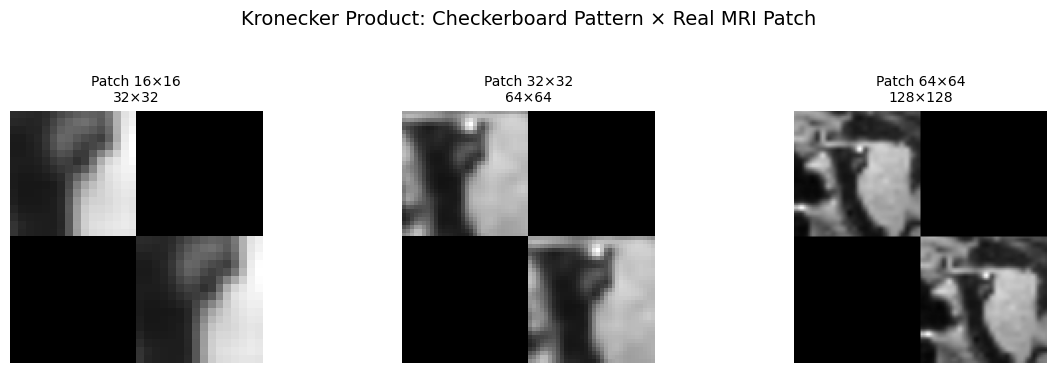

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def load_image(path, size=None):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Image not found: {path}")
    if size is not None:
        img = cv2.resize(img, (size, size))
    return img.astype(np.float32) / 255.0

def main():
    img = load_image("/content/002_S_0619_axial_z050.png", size=256)
    h, w = img.shape
    patch_sizes = [16, 32, 64]
    tile = np.array([[1, 0], [0, 1]])

    fig, axes = plt.subplots(1, len(patch_sizes), figsize=(4*len(patch_sizes), 4))
    fig.subplots_adjust(left=0.05, right=0.95, bottom=0.1, top=0.85, wspace=0.25)

    for idx, psize in enumerate(patch_sizes):
        cy, cx = h // 2, w // 2
        patch = img[cy - psize//2 : cy + psize//2,
                    cx - psize//2 : cx + psize//2]
        large = np.kron(tile, patch)

        axes[idx].imshow(large, cmap='gray')
        axes[idx].set_title(f"Patch {psize}×{psize}\n{large.shape[0]}×{large.shape[1]}", fontsize=10)
        axes[idx].axis('off')

    fig.suptitle("Kronecker Product: Checkerboard Pattern × Real MRI Patch", fontsize=14, y=0.92)
    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.show()

if __name__ == "__main__":
    main()

#  Building a Two-Dimensional Filter from One-Dimensional Filters

A two-dimensional filter can be constructed from two one-dimensional filters using the **outer product**.

Consider the one-dimensional filter

$$
g =
\begin{bmatrix}
1 & 4 & 6 & 4 & 1
\end{bmatrix}.
$$

The corresponding two-dimensional filter is

$$
K = g^\top g,
$$

where each element of $K$ is the product of one horizontal and one vertical filter coefficient.


## Interpretation

The resulting filter is **separable**, meaning it can be represented as the outer product of two one-dimensional filters.

Instead of applying a single two-dimensional convolution, the same result can be obtained by applying:

1. a one-dimensional filter along one axis, and
2. a one-dimensional filter along the other axis.


## Insight

Separable filters reduce computational cost while producing the same output as the corresponding two-dimensional filter. This property is widely used in image processing and computer vision for efficient filtering operations such as Gaussian smoothing.

Max diff: 1.7881393e-07


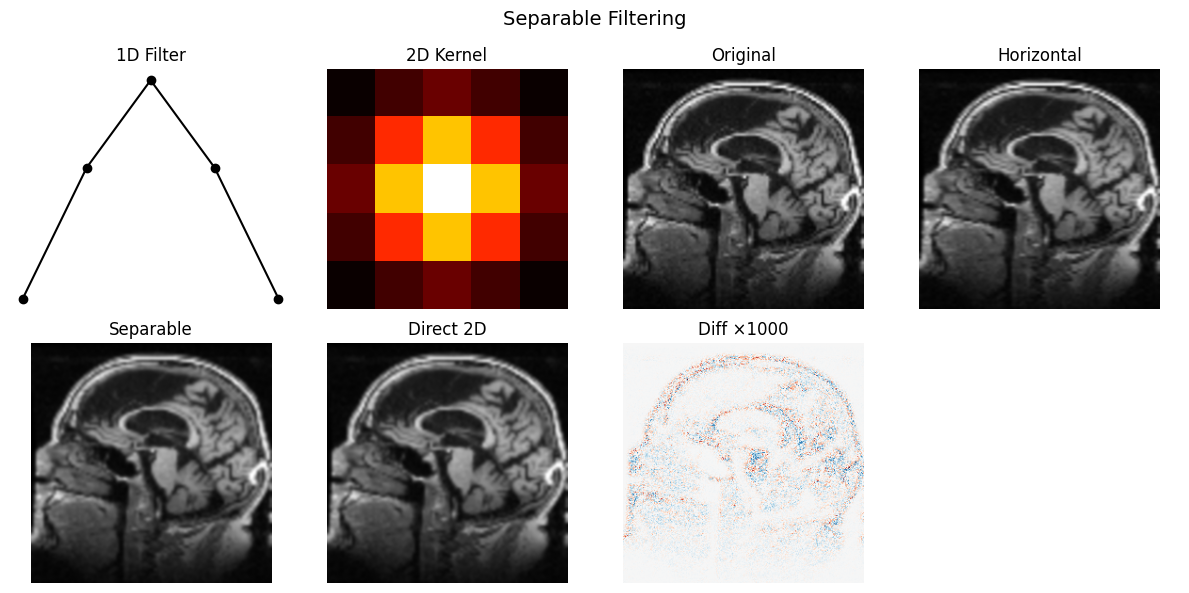

2D: 25 mult/pixel | Sep: 10 mult/pixel


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.signal import convolve2d

img = cv2.imread("/content/002_S_0619_axial_z050.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (256, 256)).astype(np.float32) / 255.0

# 1D Gaussian filter
g = np.array([1, 4, 6, 4, 1], dtype=np.float32)
g /= g.sum()

# 2D separable kernel
kernel = np.outer(g, g)

# Direct 2D convolution
filtered_2d = convolve2d(img, kernel, mode='same', boundary='symm')

# Separable convolution (two 1D passes)
intermediate = convolve2d(img, g.reshape(1, -1), mode='same', boundary='symm')
filtered_sep = convolve2d(intermediate, g.reshape(-1, 1), mode='same', boundary='symm')

print("Max diff:", np.max(np.abs(filtered_2d - filtered_sep)))

# Visualisation
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Separable Filtering", fontsize=14)
axes[0, 0].plot(g, 'o-', color='black')
axes[0, 0].set_title("1D Filter")
axes[0, 1].imshow(kernel, cmap='hot')
axes[0, 1].set_title("2D Kernel")
axes[0, 2].imshow(img, cmap='gray')
axes[0, 2].set_title("Original")
axes[0, 3].imshow(intermediate, cmap='gray')
axes[0, 3].set_title("Horizontal")
axes[1, 0].imshow(filtered_sep, cmap='gray')
axes[1, 0].set_title("Separable")
axes[1, 1].imshow(filtered_2d, cmap='gray')
axes[1, 1].set_title("Direct 2D")
axes[1, 2].imshow(np.clip((filtered_2d - filtered_sep)*1000, -1, 1), cmap='RdBu')
axes[1, 2].set_title("Diff ×1000")
axes[1, 3].axis('off')
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f"2D: {kernel.size} mult/pixel | Sep: {2*len(g)} mult/pixel")

# Building Pixel Neighborhoods with the Kronecker Product

The **Kronecker product** provides a systematic way to construct the connectivity of a two-dimensional image grid from one-dimensional connections.

Consider an image with height $H$ and width $W$. Each pixel is connected to its immediate neighbors in the horizontal and vertical directions.


## Neighborhood Construction

Let:

- $I_H$ and $I_W$ be identity matrices.
- $A_H$ and $A_W$ be adjacency matrices representing one-dimensional line connections.

The two-dimensional image connectivity is constructed as

$$
\text{Horizontal connections} = I_H \otimes A_W,
$$

$$
\text{Vertical connections} = A_H \otimes I_W.
$$

Combining these two matrices produces the neighborhood structure of the entire image.


## Interpretation

The Kronecker product builds the complete image grid by repeating simple one-dimensional connectivity patterns across rows and columns.

Each pixel is connected to its neighboring pixels without explicitly defining every individual connection.


## Insight

The Kronecker product generates large image neighborhood structures from simple one-dimensional building blocks, providing an efficient representation of pixel connectivity for image processing, graph-based methods, and scientific computing.

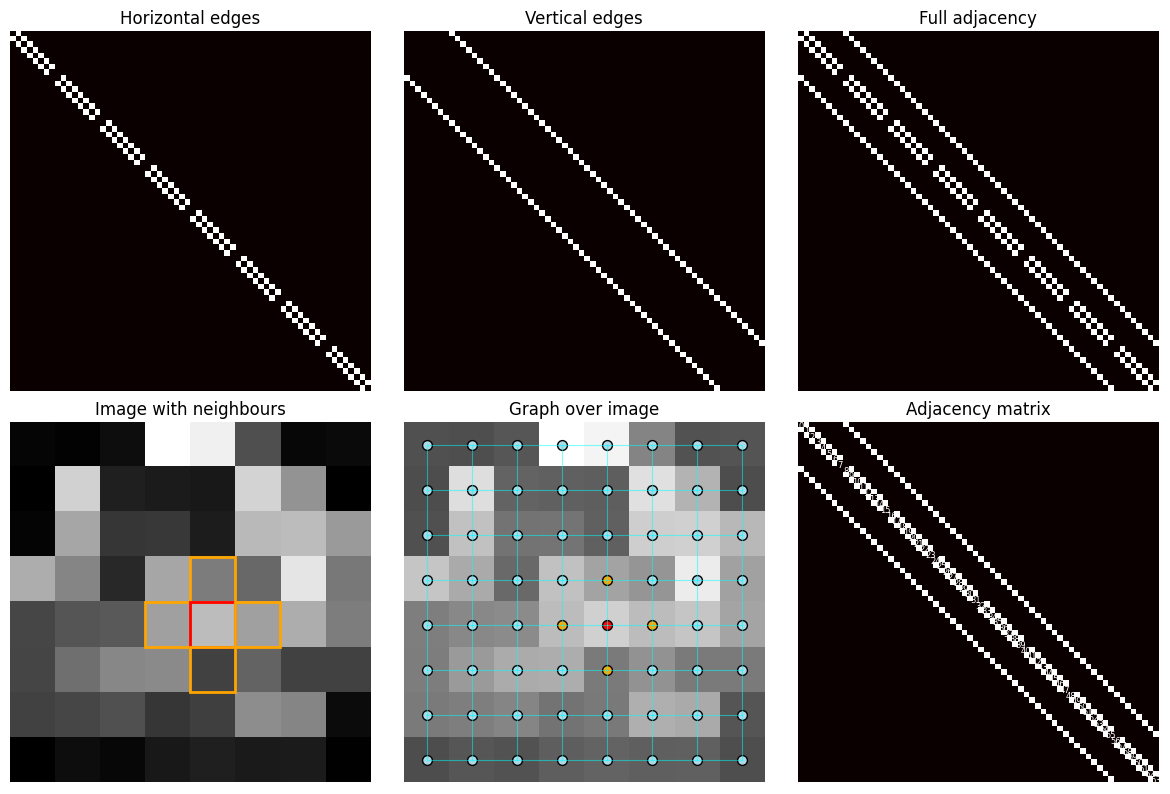

Grid: 8×8 = 64 pixels
Horizontal edges: 56
Vertical edges:   56
Total edges:      112


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def line_adj(n):
    A = np.zeros((n, n), dtype=np.int8)
    for i in range(n - 1):
        A[i, i+1] = A[i+1, i] = 1
    return A

def grid_adj(H, W):
    Ih = np.eye(H, dtype=np.int8)
    Iw = np.eye(W, dtype=np.int8)
    Ah = line_adj(H)
    Aw = line_adj(W)
    h_edges = np.kron(Ih, Aw)
    v_edges = np.kron(Ah, Iw)
    adj = h_edges + v_edges
    adj = (adj > 0).astype(np.int8)
    return adj, h_edges, v_edges

# Load real MRI slice
img = cv2.imread("/content/002_S_0619_axial_z050.png", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Image not found")
H, W = 8, 8
img_small = cv2.resize(img, (W, H)).astype(np.float32) / 255.0

adj, h_edges, v_edges = grid_adj(H, W)
N = H * W

# Display
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0,0].imshow(h_edges, cmap='hot', interpolation='nearest')
axes[0,0].set_title("Horizontal edges")
axes[0,0].axis('off')
axes[0,1].imshow(v_edges, cmap='hot', interpolation='nearest')
axes[0,1].set_title("Vertical edges")
axes[0,1].axis('off')
axes[0,2].imshow(adj, cmap='hot', interpolation='nearest')
axes[0,2].set_title("Full adjacency")
axes[0,2].axis('off')

pix = N//2 + W//2
row, col = divmod(pix, W)
nbrs = np.where(adj[pix, :])[0]

axes[1,0].imshow(img_small, cmap='gray')
axes[1,0].set_title("Image with neighbours")
axes[1,0].axis('off')
for i in range(H):
    for j in range(W):
        idx = i*W + j
        if idx == pix:
            axes[1,0].add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor='red', lw=2))
        elif idx in nbrs:
            axes[1,0].add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor='orange', lw=2))

axes[1,1].imshow(img_small, cmap='gray', alpha=0.7)
for i in range(N):
    for j in range(i+1, N):
        if adj[i, j]:
            ri, ci = divmod(i, W)
            rj, cj = divmod(j, W)
            axes[1,1].plot([ci, cj], [ri, rj], 'cyan', lw=0.8, alpha=0.5)
for i in range(H):
    for j in range(W):
        idx = i*W + j
        color = 'red' if idx == pix else 'orange' if idx in nbrs else 'lightblue'
        axes[1,1].scatter(j, i, s=50, c=color, edgecolors='black')
axes[1,1].set_title("Graph over image")
axes[1,1].axis('off')

axes[1,2].imshow(adj, cmap='hot', interpolation='nearest')
axes[1,2].set_title("Adjacency matrix")
axes[1,2].axis('off')
for i in range(N):
    axes[1,2].text(i, i, str(i), color='white', fontsize=6, ha='center', va='center')

plt.tight_layout()
plt.show()

print(f"Grid: {H}×{W} = {N} pixels")
print(f"Horizontal edges: {h_edges.sum()//2}")
print(f"Vertical edges:   {v_edges.sum()//2}")
print(f"Total edges:      {adj.sum()//2}")

#  Multi-Modal Feature Expansion with the Kronecker Product


Features from different data sources can be combined using the **Kronecker product** to explicitly represent interactions between them.

Consider:

- MRI feature vector with **64** features
- Clinical feature vector with **10** features

Let

$$
m \in \mathbb{R}^{64},
\qquad
c \in \mathbb{R}^{10}.
$$

Their Kronecker product is

$$
m \otimes c \in \mathbb{R}^{640},
$$

producing a feature vector that contains all pairwise interactions between MRI and clinical features.


## Interpretation

Two common approaches for combining features are:

- **Concatenation:** $64 + 10 = 74$ features
- **Kronecker product:** $64 \times 10 = 640$ interaction features

Each interaction feature represents the product of one MRI feature and one clinical feature.


## Insight

The Kronecker product explicitly models relationships between different feature sets by generating all pairwise interactions. This produces a richer feature representation than simple concatenation and is widely used for combining information from multiple data sources in machine learning and medical image analysis.

MRI features:      (64,)
Clinical features: (10,)
Interaction:       (640,)


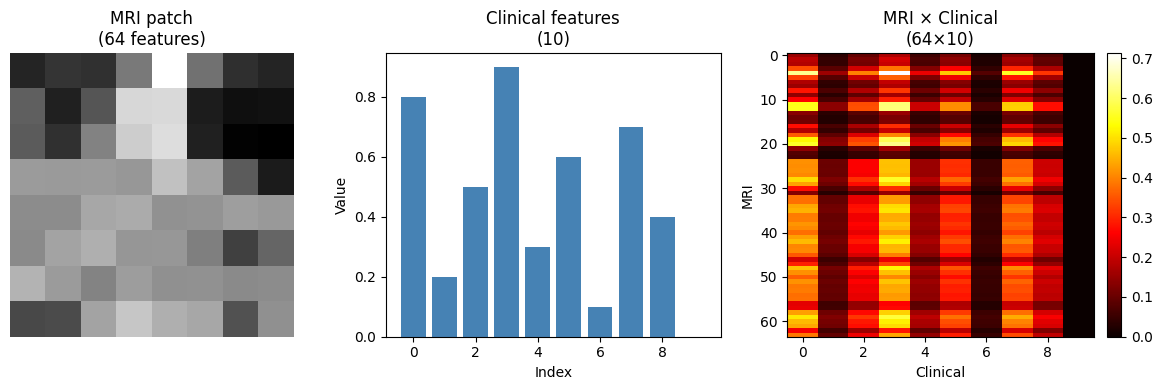

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("/content/002_S_0619_axial_z050.png", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Image not found")
img = cv2.resize(img, (64, 64)).astype(np.float32) / 255.0
patch = img[20:28, 20:28].flatten()

clinical = np.array([0.8, 0.2, 0.5, 0.9, 0.3, 0.6, 0.1, 0.7, 0.4, 0.0], dtype=np.float32)

interaction = np.kron(patch, clinical)

print(f"MRI features:      {patch.shape}")
print(f"Clinical features: {clinical.shape}")
print(f"Interaction:       {interaction.shape}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(patch.reshape(8, 8), cmap='gray')
axes[0].set_title(f"MRI patch\n({len(patch)} features)")
axes[0].axis('off')

axes[1].bar(range(len(clinical)), clinical, color='steelblue')
axes[1].set_title(f"Clinical features\n({len(clinical)})")
axes[1].set_xlabel("Index")
axes[1].set_ylabel("Value")

axes[2].imshow(interaction.reshape(len(patch), len(clinical)), cmap='hot', aspect='auto')
axes[2].set_title(f"MRI × Clinical\n({len(patch)}×{len(clinical)})")
axes[2].set_xlabel("Clinical")
axes[2].set_ylabel("MRI")
plt.colorbar(axes[2].images[0], ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Building a 3D Volume from a 2D Slice

The **Kronecker product** can be used to construct a three-dimensional volume by repeating a two-dimensional image along a new depth dimension.

Let

$$
S \in \mathbb{R}^{H \times W}
$$

be a single image slice.

Adding a new axis gives

$$
S \in \mathbb{R}^{1 \times H \times W}.
$$

Repeating the slice across 32 depth levels produces

$$
V \in \mathbb{R}^{32 \times H \times W}.
$$


## Interpretation

The construction consists of four steps:

1. Begin with a two-dimensional image of shape $(H, W)$.
2. Add a depth dimension to obtain $(1, H, W)$.
3. Create a depth pattern with shape $(32, 1, 1)$.
4. Apply the Kronecker product to replicate the slice across all depth levels.

The resulting tensor represents a three-dimensional volume in which every slice is initially identical.


## Insight

The Kronecker product provides a simple way to construct volumetric data from a single image by replicating it along a new dimension. Although all slices are initially identical, individual slices can later be modified to simulate changes across depth, making this a useful technique for generating synthetic volumetric datasets and illustrating three-dimensional tensor representations.

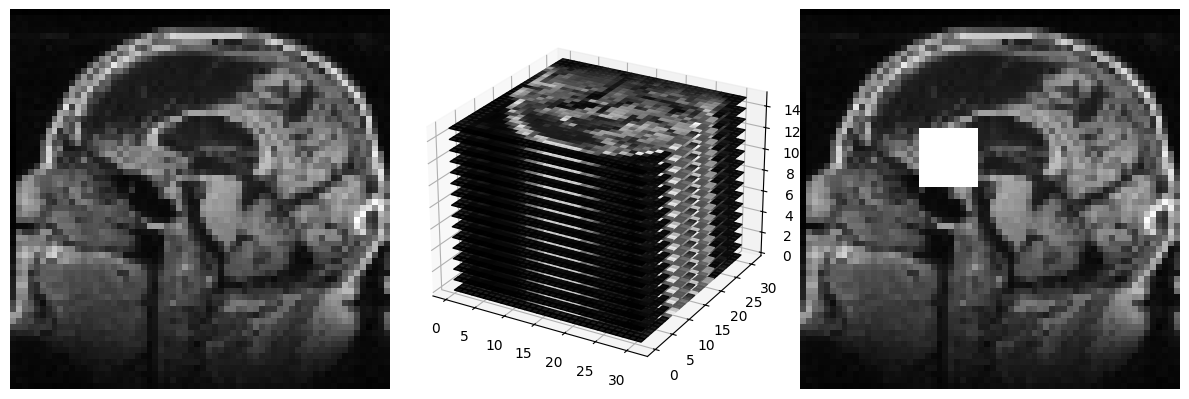

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import cv2

img = cv2.imread("/content/002_S_0619_axial_z050.png", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Image not found")
img = cv2.resize(img, (64, 64)).astype(np.float32) / 255.0

H, W = img.shape
depth = 32

volume = np.kron(np.ones((depth, 1, 1)), img[None, :, :])

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(131)
ax1.imshow(img, cmap='gray')
ax1.axis('off')

ax2 = fig.add_subplot(132, projection='3d')
step = 2
vol_ds = volume[::step, ::step, ::step]
d, h, w = vol_ds.shape
norm = plt.Normalize(vmin=vol_ds.min(), vmax=vol_ds.max())
for z in range(d):
    X, Y = np.meshgrid(np.arange(w), np.arange(h))
    Z = np.full_like(X, z)
    ax2.plot_surface(X, Y, Z,
                     facecolors=plt.cm.gray(norm(vol_ds[z])),
                     rstride=1, cstride=1, alpha=0.9, shade=False)
ax2.view_init(elev=25, azim=-60)

vol_mod = volume.copy()
vol_mod[10, 20:30, 20:30] = 1.0
ax3 = fig.add_subplot(133)
ax3.imshow(vol_mod[10], cmap='gray')
ax3.axis('off')

plt.tight_layout()
plt.show()

# Resolution Scaling with the Kronecker Product

The **Kronecker product** can increase image resolution by replacing each pixel with a larger block of identical values.

Let

$$
I \in \mathbb{R}^{128 \times 128}
$$

be a grayscale image.

Applying the Kronecker product with a block of ones produces

$$
I \otimes \mathbf{1}_{k \times k},
$$

where $k$ is the scaling factor.


## Interpretation

Each pixel in the original image is expanded into a square block of identical values.

Common scaling factors include:

- $k = 2$ → each pixel becomes a $2 \times 2$ block
- $k = 4$ → each pixel becomes a $4 \times 4$ block
- $k = 8$ → each pixel becomes an $8 \times 8$ block

The enlarged image preserves the original pixel values while increasing its spatial resolution.

## Insight

Using a matrix of ones, the Kronecker product performs image upsampling through structured repetition of pixel values. This produces the same result as nearest-neighbor upsampling, where each pixel is replicated into a larger block without introducing new intensity values.

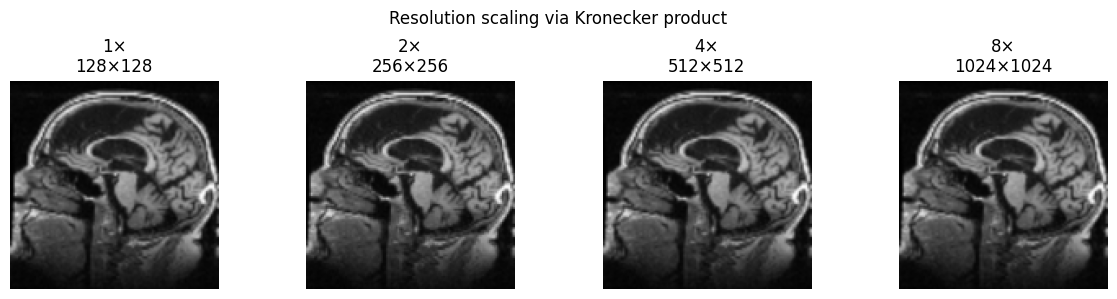

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("/content/002_S_0619_axial_z050.png", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Image not found")
img = cv2.resize(img, (128, 128)).astype(np.float32) / 255.0

scales = [1, 2, 4, 8]
upsampled = [np.kron(img, np.ones((s, s))) for s in scales]

fig, axes = plt.subplots(1, len(scales), figsize=(12, 3))
for ax, im, s in zip(axes, upsampled, scales):
    ax.imshow(im, cmap='gray')
    ax.set_title(f"{s}×\n{im.shape[0]}×{im.shape[1]}")
    ax.axis('off')
plt.suptitle("Resolution scaling via Kronecker product")
plt.tight_layout()
plt.show()

# Feature Interaction Heatmap

The **Kronecker product** can be used to generate interaction features between two different feature sets.

Consider:

- **Radiomic features:** 10 features
- **Clinical features:** 3 features

Let

$$
r \in \mathbb{R}^{10},
\qquad
c \in \mathbb{R}^{3}.
$$

Their Kronecker product is

$$
r \otimes c \in \mathbb{R}^{30},
$$

which contains every pairwise interaction between the radiomic and clinical features.


## Interpretation

Each interaction feature is the product of one radiomic feature and one clinical feature.

For visualization, the interaction vector can be reshaped into a

$$
10 \times 3
$$

matrix, where:

- Rows correspond to radiomic features.
- Columns correspond to clinical features.
- Each cell represents one interaction between the two feature sets.


## Insight

The Kronecker product systematically generates pairwise interaction features, providing a richer representation than simple feature concatenation. Visualizing the interaction matrix helps reveal how features from different data sources combine and serves as a useful tool for exploring cross-modal relationships in medical AI.

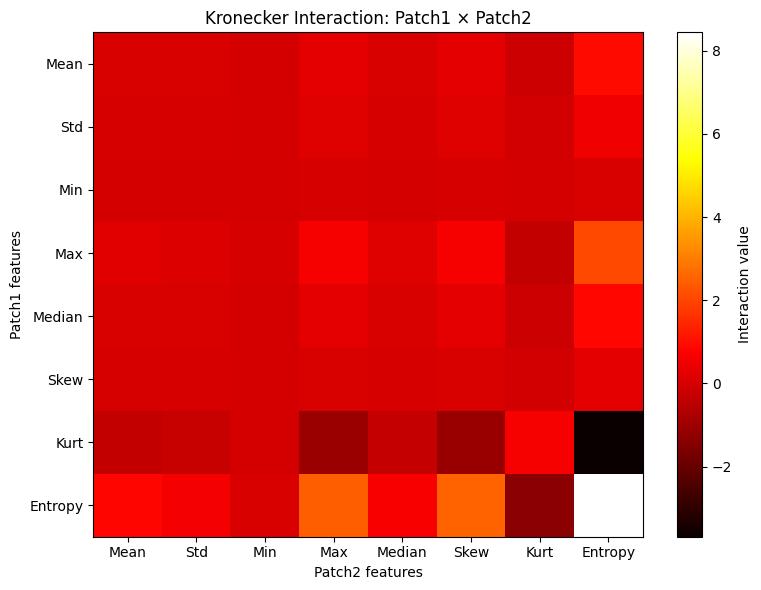

Strongest interactions (by magnitude):
  Entropy × Entropy: 8.4431
  Kurt × Entropy: -3.6859
  Entropy × Skew: 2.5235
  Entropy × Max: 2.4635
  Max × Entropy: 2.0830


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.stats import entropy, skew, kurtosis

img = cv2.imread("/content/002_S_0619_axial_z050.png", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Image not found")
img = cv2.resize(img, (128, 128)).astype(np.float32) / 255.0

patch1 = img[48:80, 48:80]
patch2 = img[20:52, 20:52]

def radiomics(patch):
    flat = patch.flatten()
    hist, _ = np.histogram(flat, bins=32, range=(0,1))
    hist = hist / (np.sum(hist) + 1e-8)
    return np.array([
        np.mean(flat), np.std(flat), np.min(flat), np.max(flat),
        np.median(flat), skew(flat), kurtosis(flat), entropy(hist)
    ], dtype=np.float32)

f1 = radiomics(patch1)
f2 = radiomics(patch2)

# Kronecker interaction matrix
interaction = np.kron(f1, f2)
mat = interaction.reshape(len(f1), len(f2))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(mat, cmap='hot', aspect='auto')
ax.set_title("Kronecker Interaction: Patch1 × Patch2")
ax.set_xlabel("Patch2 features")
ax.set_ylabel("Patch1 features")
labels = ["Mean", "Std", "Min", "Max", "Median", "Skew", "Kurt", "Entropy"]
ax.set_xticks(range(len(f2)))
ax.set_yticks(range(len(f1)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.colorbar(im, label="Interaction value")
plt.tight_layout()
plt.show()

idx = np.argsort(np.abs(mat.ravel()))[::-1]
print("Strongest interactions (by magnitude):")
for i in idx[:5]:
    r = i // len(f2)
    c = i % len(f2)
    print(f"  {labels[r]} × {labels[c]}: {mat[r, c]:.4f}")

# Building Synthetic Multi-Channel Data

The **Kronecker product** can generate multiple synthetic image channels by combining a base anatomical image with different contrast and noise patterns.

Let

$$
I \in \mathbb{R}^{H \times W}
$$

be a base image,

$$
c \in \mathbb{R}^{C}
$$

be a vector of contrast scaling factors, and

$$
n \in \mathbb{R}^{C}
$$

be a vector of noise scaling factors.

Applying the Kronecker product creates

- a set of contrast-scaled images, and
- a corresponding set of noise images,

which are combined to form a multi-channel tensor

$$
X \in \mathbb{R}^{C \times H \times W}.
$$


## Interpretation

Each channel represents the same anatomical image with a different appearance.

The variations arise from:

- Different contrast scaling factors.
- Different noise levels.
- A shared underlying anatomical structure.

The resulting tensor therefore contains multiple synthetic image channels generated from a single base image.


## Insight

The Kronecker product provides a simple way to construct structured multi-channel image data by systematically combining anatomical patterns with different contrast and noise variations. This illustrates how synthetic datasets can be generated efficiently while preserving consistent spatial structure across channels.

Output tensor: (4, 64, 64)


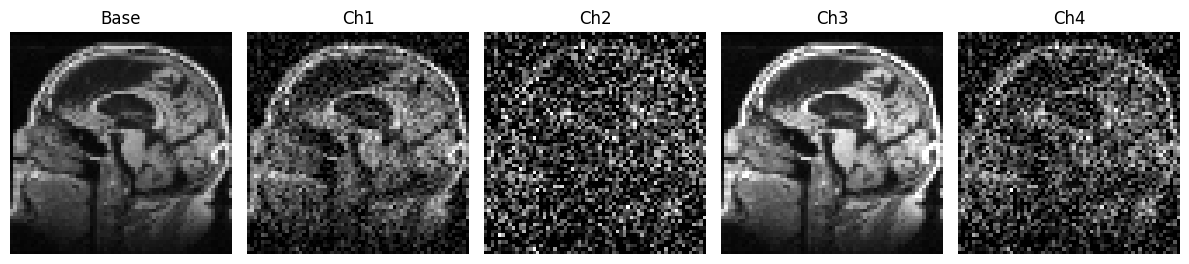

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("/content/002_S_0619_axial_z050.png", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Image not found")
base = cv2.resize(img, (64, 64)).astype(np.float32) / 255.0
H, W = base.shape

contrast = np.array([1.0, 0.6, 1.4, 0.8], dtype=np.float32)
np.random.seed(42)
noise_pattern = np.random.randn(H, W).astype(np.float32)
noise_levels = np.array([0.1, 0.3, 0.0, 0.2], dtype=np.float32)

scaled_base = np.kron(contrast[:, None], base.reshape(1, -1)).reshape(len(contrast), H, W)
noise_vol = np.kron(noise_levels[:, None], noise_pattern.reshape(1, -1)).reshape(len(noise_levels), H, W)
synthetic = np.clip(scaled_base + noise_vol, 0, 1)

print(f"Output tensor: {synthetic.shape}")

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(base, cmap='gray')
axes[0].set_title("Base")
axes[0].axis('off')
for i in range(4):
    axes[i+1].imshow(synthetic[i], cmap='gray')
    axes[i+1].set_title(f"Ch{i+1}")
    axes[i+1].axis('off')
plt.tight_layout()
plt.show()

# Sparse Pattern Generation with the Kronecker Product

The **Kronecker product** can generate structured images by placing a small pattern at predefined locations.

Consider

- a **lesion pattern** represented by a small binary matrix, and
- a **placement grid** whose entries indicate where the lesion should appear.

Let

$$
L \in \mathbb{R}^{h \times w}
$$

be the lesion pattern, and

$$
G \in \{0,1\}^{m \times n}
$$

be a binary placement grid.

The Kronecker product

$$
G \otimes L
$$

produces a larger image in which every value of **1** in the grid is replaced by the lesion pattern, while every value of **0** becomes an equally sized block of zeros.


## Interpretation

The placement grid determines the lesion locations, while the lesion pattern determines the appearance of each lesion.

Changing the grid modifies:

- The lesion locations.
- The number of lesions.
- The spatial arrangement.

Changing the lesion pattern modifies:

- The lesion size.
- The lesion shape.


## Insight

The Kronecker product provides a simple way to generate structured synthetic images by combining a placement grid with a template pattern. This approach is useful for creating controlled synthetic datasets for image analysis, segmentation experiments, and algorithm development.

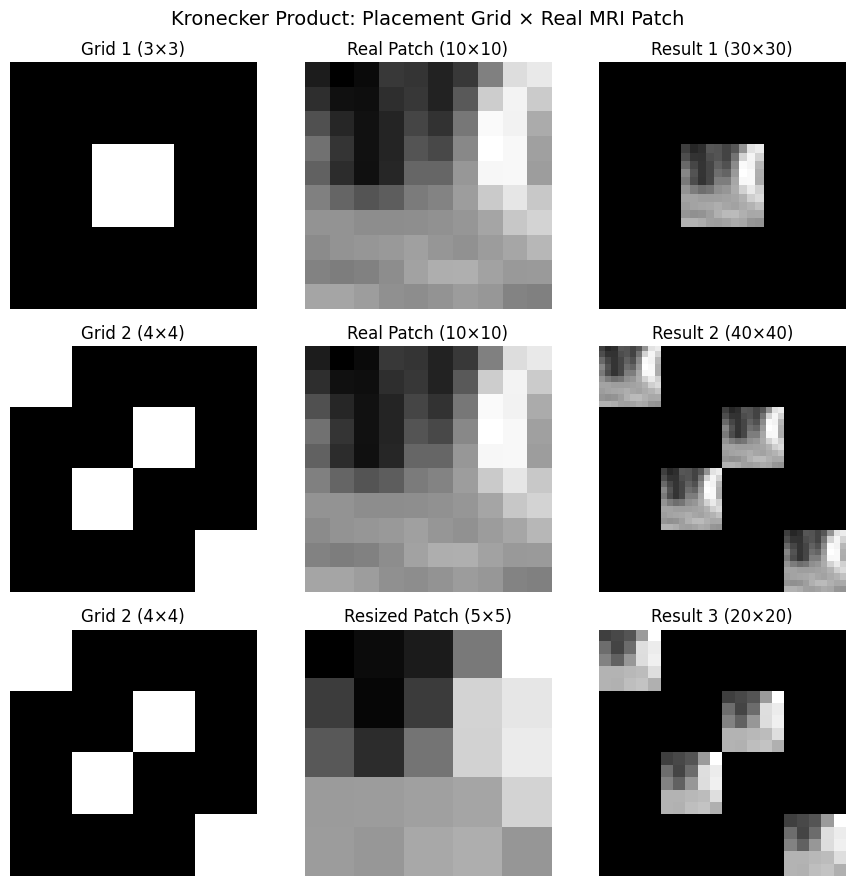

Shape transformations:
  Grid 1 (3, 3) × Patch (10, 10) → (30, 30)
  Grid 2 (4, 4) × Patch (10, 10) → (40, 40)
  Grid 2 (4, 4) × Small patch (5, 5) → (20, 20)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("/content/002_S_0619_axial_z050.png", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Image not found")
img = cv2.resize(img, (128, 128)).astype(np.float32) / 255.0

lesion = img[40:50, 40:50]

grid1 = np.zeros((3, 3), dtype=np.float32)
grid1[1, 1] = 1

grid2 = np.zeros((4, 4), dtype=np.float32)
grid2[0, 0] = grid2[1, 2] = grid2[2, 1] = grid2[3, 3] = 1

img1 = np.kron(grid1, lesion)
img2 = np.kron(grid2, lesion)

small_lesion = cv2.resize(lesion, (5, 5), interpolation=cv2.INTER_AREA)
img3 = np.kron(grid2, small_lesion)

fig, axes = plt.subplots(3, 3, figsize=(9, 9))

axes[0, 0].imshow(grid1, cmap='gray', interpolation='nearest')
axes[0, 0].set_title("Grid 1 (3×3)")
axes[0, 0].axis('off')
axes[0, 1].imshow(lesion, cmap='gray')
axes[0, 1].set_title("Real Patch (10×10)")
axes[0, 1].axis('off')
axes[0, 2].imshow(img1, cmap='gray')
axes[0, 2].set_title("Result 1 (30×30)")
axes[0, 2].axis('off')

axes[1, 0].imshow(grid2, cmap='gray', interpolation='nearest')
axes[1, 0].set_title("Grid 2 (4×4)")
axes[1, 0].axis('off')
axes[1, 1].imshow(lesion, cmap='gray')
axes[1, 1].set_title("Real Patch (10×10)")
axes[1, 1].axis('off')
axes[1, 2].imshow(img2, cmap='gray')
axes[1, 2].set_title("Result 2 (40×40)")
axes[1, 2].axis('off')

axes[2, 0].imshow(grid2, cmap='gray', interpolation='nearest')
axes[2, 0].set_title("Grid 2 (4×4)")
axes[2, 0].axis('off')
axes[2, 1].imshow(small_lesion, cmap='gray')
axes[2, 1].set_title("Resized Patch (5×5)")
axes[2, 1].axis('off')
axes[2, 2].imshow(img3, cmap='gray')
axes[2, 2].set_title("Result 3 (20×20)")
axes[2, 2].axis('off')

plt.suptitle("Kronecker Product: Placement Grid × Real MRI Patch", fontsize=14)
plt.tight_layout()
plt.show()

print("Shape transformations:")
print(f"  Grid 1 {grid1.shape} × Patch {lesion.shape} → {img1.shape}")
print(f"  Grid 2 {grid2.shape} × Patch {lesion.shape} → {img2.shape}")
print(f"  Grid 2 {grid2.shape} × Small patch {small_lesion.shape} → {img3.shape}")